<a href="https://colab.research.google.com/github/gitanisa008/project/blob/main/train_palm_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palm Oil Detection - YOLOv8
**Input:** ArcGIS Image Chips (KITTI format)  
**Output:** Model `.pt` untuk deteksi pohon sawit

---
### Sebelum mulai:
1. Runtime → Change runtime type → **GPU (T4)**
2. Upload folder export ArcGIS ke Google Drive
3. Jalankan cell satu per satu dari atas ke bawah

## Step 1: Install YOLOv8

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO
print('YOLOv8 ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 ready!


## Step 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['KEBUM', 'PROYEK TASIK', 'Layout', 'CV_GITANISA AULIA SANDY.docx', 'Colab Notebooks', 'Ijazah-Digital-15120008.pdf', 'ijazah_GITANISA AULIA.pdf', 'ijazah', 'FOTO_GITANISA AULIA_MANAGEMENT TRAINEE.jpg', 'toefl_gitanisa.pdf', 'GITANISA AULIA_CV (8).pdf', 'GITANISA AULIA_CV (7).pdf', 'GITANISA AULIA_CV (6).pdf', 'KTP_GITANISA_WM.PDF', 'GITANISA AULIA_CV (1).docx', 'GITANISA AULIA_CV_COVERLETTER.pdf', 'GITANISA AULIA_CV.docx', 'GITANISA AULIA_CV (5).pdf', 'GITANISA AULIA_CV (4).pdf', 'GITANISA AULIA_CV (3).pdf', 'GITANISA AULIA_CV (2).pdf', 'CV_GITANISA AULIA (1).pdf', 'CV_GITANISA AULIA.pdf', 'CV_GITANISA AULIA_MANAGEMENT TRAINEE.pdf', 'GITANISA AULIA_CV (1).pdf', 'GITANISA AULIA_CV.pdf', 'image_chips', 'palm_yolo_output', ' Perhitungan Gugatan [Gitanisa Aulia].gsheet']


## Step 3: Set Path
Ganti sesuai nama folder export kamu di Google Drive

In [ ]:
# GANTI INI
TRAINING_PATH = '/content/drive/MyDrive/image_chips'
OUTPUT_PATH   = '/content/drive/MyDrive/palm_yolo_output'

print('Training data:', TRAINING_PATH)
print('Output model :', OUTPUT_PATH)

Training data: /content/drive/MyDrive/image_chips
Output model : /content/drive/MyDrive/palm_yolo_output


## Step 4: Cek GPU

In [ ]:
import torch
print('GPU tersedia :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU          :', torch.cuda.get_device_name(0))
    print('VRAM         :', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')
else:
    print('WARNING: Ganti runtime ke GPU dulu!')

GPU tersedia : True
GPU          : Tesla T4
VRAM         : 14.6 GB


## Step 5: Cek Ukuran Image Chips

In [ ]:
import shutil
shutil.rmtree('/content/dataset')
print('Terhapus!')

Terhapus!


In [ ]:
from PIL import Image

images = [f for f in os.listdir(f'{TRAINING_PATH}/images')
          if f.endswith(('.jpg', '.png', '.tif', '.tiff'))]

sample = images[0]
img = Image.open(f'{TRAINING_PATH}/images/{sample}')

IMG_W, IMG_H = img.size
print('Ukuran chip  :', img.size)
print('Contoh file  :', sample)
print('Total images :', len(images))

Ukuran chip  : (256, 256)
Contoh file  : 000000011562.tif
Total images : 4087


## Step 6: Konversi KITTI → YOLO

In [ ]:
import shutil

os.makedirs('dataset/images/train', exist_ok=True)
os.makedirs('dataset/labels/train', exist_ok=True)

# Copy images (skip .tfw dll)
for f in os.listdir(f'{TRAINING_PATH}/images'):
    if f.endswith(('.jpg', '.png', '.tif', '.tiff')):
        shutil.copy(f'{TRAINING_PATH}/images/{f}', 'dataset/images/train/')

# Konversi label KITTI → YOLO
skipped = 0
converted = 0
for txt in os.listdir(f'{TRAINING_PATH}/labels'):
    if not txt.endswith('.txt'):
        continue
    with open(f'{TRAINING_PATH}/labels/{txt}') as f:
        lines = f.readlines()
    yolo_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 8:
            skipped += 1
            continue
        cls = 0  # palm = kelas 0
        x1, y1, x2, y2 = float(parts[4]), float(parts[5]), float(parts[6]), float(parts[7])
        cx = ((x1 + x2) / 2) / IMG_W
        cy = ((y1 + y2) / 2) / IMG_H
        w  = (x2 - x1) / IMG_W
        h  = (y2 - y1) / IMG_H
        yolo_lines.append(f'{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    with open(f'dataset/labels/train/{txt}', 'w') as f:
        f.write('\n'.join(yolo_lines))
    converted += 1

print('Konversi selesai!')
print('Total images :', len(os.listdir('dataset/images/train')))
print('Total labels :', converted)
print('Baris skipped:', skipped)

Konversi selesai!
Total images : 4087
Total labels : 4070
Baris skipped: 0


## Step 7: Buat Konfigurasi Dataset (palm.yaml)

In [ ]:
yaml_content = f"""path: /content/dataset
train: images/train
val: images/train

nc: 1
names:
  0: palm
"""

with open('palm.yaml', 'w') as f:
    f.write(yaml_content)

print('palm.yaml siap!')
print(yaml_content)

palm.yaml siap!
path: /content/dataset
train: images/train
val: images/train

nc: 1
names:
  0: palm



## Step 8: Training

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # nano = ringan, cocok untuk porto

results = model.train(
    data='palm.yaml',
    epochs=100,
    imgsz=256,
    batch=16,
    project=OUTPUT_PATH,
    name='palm_detection',
    save=True
)

print('Training selesai!')
print('Model tersimpan di:', OUTPUT_PATH)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=palm.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=palm_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

## Step 9: Evaluasi Hasil

In [ ]:
# Load model terbaik hasil training
best_model = YOLO(f'{OUTPUT_PATH}/palm_detection/weights/best.pt')

# Validasi
metrics = best_model.val(data='palm.yaml')
print('mAP50   :', round(metrics.box.map50, 4))
print('mAP50-95:', round(metrics.box.map, 4))

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3441.4±1132.3 MB/s, size: 188.2 KB)
val: Scanning /content/dataset/labels/train.cache... 4070 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4087/4087 311.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 256/256 7.8it/s 32.9s
                   all       4087      10486      0.808      0.675       0.77      0.617
Speed: 0.3ms preprocess, 1.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP50   : 0.7696
mAP50-95: 0.6168



image 1/1 /content/dataset/images/train/000000004827.tif: 256x256 3 palms, 9.2ms
Speed: 0.6ms preprocess, 9.2ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 256)
Results saved to /content/predictions/predict

image 1/1 /content/dataset/images/train/000000011687.tif: 256x256 3 palms, 6.1ms
Speed: 0.5ms preprocess, 6.1ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 256)
Results saved to /content/predictions/predict-2

image 1/1 /content/dataset/images/train/000000010096.tif: 256x256 1 palm, 6.2ms
Speed: 0.5ms preprocess, 6.2ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 256)
Results saved to /content/predictions/predict-3


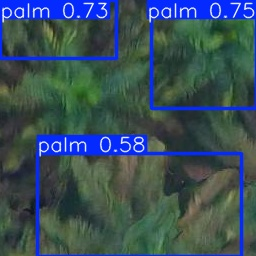

In [ ]:
# Visualisasi prediksi pada sample gambar
import glob
from IPython.display import Image as IPImage, display

sample_imgs = glob.glob('dataset/images/train/*.tif')[:3]

for img_path in sample_imgs:
    result = best_model.predict(img_path, conf=0.3, save=True,
                                project='/content/predictions')

# Tampilkan hasil
pred_imgs = glob.glob('/content/predictions/predict/*.jpg')[:3]
for p in pred_imgs:
    display(IPImage(p))

In [ ]:
from ultralytics import YOLO

model = YOLO(f'{OUTPUT_PATH}/palm_detection/weights/best.pt')

# Export ke format ONNX
model.export(format='onnx')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/palm_yolo_output/palm_detection/weights/best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 5, 1344) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 242ms
Prepared 4 packages in 7.33s
Installed 4 packages in 294ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 8.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.2

'/content/drive/MyDrive/palm_yolo_output/palm_detection/weights/best.onnx'

In [ ]:
import json

emd = {
    "Framework": "PyTorch",
    "ModelConfiguration": "FastaiSSD",
    "ModelFile": "best.onnx",
    "ModelType": "ObjectDetection",
    "ImageWidth": 256,
    "ImageHeight": 256,
    "ImageSpaceUsed": "MAP_SPACE",
    "NormalizationStats": {
        "band_min_values": [0, 0, 0],
        "band_max_values": [255, 255, 255],
        "band_mean_values": [0, 0, 0],
        "band_std_values": [1, 1, 1],
        "scaled_min_values": [0, 0, 0],
        "scaled_max_values": [1, 1, 1]
    },
    "Classes": [
        {"Value": 0, "Name": "palm", "Color": [255, 0, 0]}
    ]
}

with open(f'{OUTPUT_PATH}/palm_detection/weights/best.emd', 'w') as f:
    json.dump(emd, f, indent=2)

print('Done!')

Done!


In [ ]:
import zipfile
import os

weights_path = f'{OUTPUT_PATH}/palm_detection/weights'
dlpk_path = f'{OUTPUT_PATH}/palm_detection/palm_oil.dlpk'

with zipfile.ZipFile(dlpk_path, 'w') as z:
    z.write(f'{weights_path}/best.onnx', 'best.onnx')
    z.write(f'{weights_path}/best.emd', 'best.emd')

print('DLPK siap di:', dlpk_path)

DLPK siap di: /content/drive/MyDrive/palm_yolo_output/palm_detection/palm_oil.dlpk


# **Step 10: EXPORT HASIL TEST**

In [ ]:
# import geopandas as gpd
# from shapely.geometry import box
# from ultralytics import YOLO
# import rasterio
# from rasterio.windows import Window
# import numpy as np
# from PIL import Image

# # Load model
# model = YOLO(f'{OUTPUT_PATH}/palm_detection/weights/best.pt')

# # Load raster
# raster_path = '/content/drive/MyDrive/5eef8c4c1bb60b000624b4f3.tif'  # ganti ini

# results_list = []

# with rasterio.open(raster_path) as src:
#     transform = src.transform
#     crs = src.crs
#     width = src.width
#     height = src.height

#     chip_size = 256

#     # Sliding window per chip 256x256
#     for row in range(0, height, chip_size):
#         for col in range(0, width, chip_size):
#             # Baca chip
#             window = Window(col, row,
#                           min(chip_size, width-col),
#                           min(chip_size, height-row))
#             chip = src.read([1,2,3], window=window)
#             chip = np.moveaxis(chip, 0, -1).astype(np.uint8)

#             # Predict
#             results = model.predict(chip, conf=0.3, verbose=False)

#             for result in results:
#                 for bbox in result.boxes.xyxy:
#                     x1, y1, x2, y2 = bbox.tolist()

#                     # Convert pixel coords → geo coords
#                     geo_x1, geo_y1 = rasterio.transform.xy(transform, row+y1, col+x1)
#                     geo_x2, geo_y2 = rasterio.transform.xy(transform, row+y2, col+x2)

#                     results_list.append({
#                         'geometry': box(geo_x1, geo_y2, geo_x2, geo_y1),
#                         'confidence': float(result.boxes.conf[0])
#                     })

# # Export ke shapefile
# gdf = gpd.GeoDataFrame(results_list, crs=crs)
# output_shp = '/content/drive/MyDrive/palm_detections.shp'
# gdf.to_file(output_shp)
# print(f'Shapefile tersimpan: {len(gdf)} pohon terdeteksi')

Shapefile tersimpan: 1810 pohon terdeteksi


In [ ]:
import geopandas as gpd
from shapely.geometry import box
from ultralytics import YOLO
import rasterio
from rasterio.windows import Window
import numpy as np
import torch

# ── PARAMETER ──────────────────────────────────────────
CONF_THRESHOLD = 0.6   # confidence minimum
NMS_IOU        = 0.4   # max overlap sebelum dianggap 1 objek
# ───────────────────────────────────────────────────────

# Load model
model = YOLO(f'{OUTPUT_PATH}/palm_detection/weights/best.pt')

# Load raster
raster_path = '/content/drive/MyDrive/sawit_projected.tif'

results_list = []

with rasterio.open(raster_path) as src:
    transform = src.transform
    crs       = src.crs
    width     = src.width
    height    = src.height
    chip_size = 256

    for row in range(0, height, chip_size):
        for col in range(0, width, chip_size):
            window = Window(col, row,
                            min(chip_size, width  - col),
                            min(chip_size, height - row))
            chip = src.read([1, 2, 3], window=window)
            chip = np.moveaxis(chip, 0, -1).astype(np.uint8)

            results = model.predict(
                chip,
                conf=CONF_THRESHOLD,   # confidence threshold 0.6
                iou=NMS_IOU,           # NMS IoU threshold 0.4
                verbose=False
            )

            for result in results:
                boxes  = result.boxes.xyxy
                confs  = result.boxes.conf

                for i, bbox in enumerate(boxes):
                    x1, y1, x2, y2 = bbox.tolist()

                    geo_x1, geo_y1 = rasterio.transform.xy(transform, row + y1, col + x1)
                    geo_x2, geo_y2 = rasterio.transform.xy(transform, row + y2, col + x2)

                    results_list.append({
                        'geometry'  : box(geo_x1, geo_y2, geo_x2, geo_y1),
                        'confidence': float(confs[i])
                    })

print(f'Total deteksi sebelum NMS global: {len(results_list)}')

# ── GLOBAL NMS antar chip ───────────────────────────────
# Chip yang overlap di border bisa deteksi objek sama 2x
# → NMS global buang duplikat antar chip

def iou(a, b):
    """Hitung IoU antara dua shapely geometry."""
    inter = a.intersection(b).area
    union = a.union(b).area
    return inter / union if union > 0 else 0

def nms_geometries(gdf, iou_threshold=0.4):
    """Non-Maximum Suppression untuk GeoDataFrame."""
    gdf = gdf.sort_values('confidence', ascending=False).reset_index(drop=True)
    keep = []
    suppressed = set()

    for i in range(len(gdf)):
        if i in suppressed:
            continue
        keep.append(i)
        for j in range(i + 1, len(gdf)):
            if j in suppressed:
                continue
            if iou(gdf.geometry[i], gdf.geometry[j]) > iou_threshold:
                suppressed.add(j)  # overlap > 40% → anggap 1 objek, buang yang confidence lebih rendah

    return gdf.iloc[keep].reset_index(drop=True)

# Buat GeoDataFrame
gdf = gpd.GeoDataFrame(results_list, crs=crs)

# Terapkan NMS global
gdf_nms = nms_geometries(gdf, iou_threshold=NMS_IOU)

print(f'Total setelah NMS global : {len(gdf_nms)}')
print(f'Duplikat dibuang         : {len(gdf) - len(gdf_nms)}')

# Export shapefile
output_shp = '/content/drive/MyDrive/palm_detectv2.shp'
gdf_nms.to_file(output_shp)
print(f'Shapefile tersimpan: {output_shp}')

Total deteksi sebelum NMS global: 728
Total setelah NMS global : 728
Duplikat dibuang         : 0
Shapefile tersimpan: /content/drive/MyDrive/palm_detectv2.shp
